# Test Amplitude Compensation for Universal GASP

This notebook validates the T2/T1 estimation and amplitude compensation approach.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')

from gasp.ssfp import ssfp
from gasp.gasp import train_gasp, run_gasp
from gasp import responses
from gasp.simulation import SSFPParams, simulate_ssfp_simple
from gasp.compensated import (
    estimate_t2_from_tr_decay,
    estimate_t1_from_profile,
    estimate_t1_t2_planet,
    normalize_signals,
    train_compensated_gasp,
    run_compensated_gasp,
)

# Acquisition parameters (matching gasp_analysis.ipynb)
TRs = [5e-3, 10e-3, 15e-3]
alpha = np.deg2rad(60)  # 60 degrees as in analysis notebook
npcs = 8  # Match analysis notebook
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

# Image dimensions
WIDTH = 256   # Spectral dimension (frequency samples)
HEIGHT = 1    # Spatial dimension

# Build SSFPParams for simulation (matches gasp_analysis.ipynb pattern)
n_acq = npcs * len(TRs)
alpha_list = [alpha] * n_acq
TR_list = []
pc_list = []
for tr in TRs:
    for pc in pcs:
        TR_list.append(tr)
        pc_list.append(pc)

PARAMS = SSFPParams(n_acq, alpha_list, TR_list, pc_list)
MIN_TR = TRs[0]

def simulate_tissue(T1, T2, width=WIDTH, height=HEIGHT):
    """Simulate bSSFP for a tissue type using SSFPParams (matching analysis notebook)."""
    M = simulate_ssfp_simple(
        width=width, height=height,
        T1=T1, T2=T2,
        params=PARAMS,
        minTR=MIN_TR
    )
    return M

def simulate_multi_tr(T1, T2, TRs, alpha, pcs, M0=1.0):
    """Simulate multi-TR phase-cycled bSSFP signal for a single voxel (on-resonance)."""
    signals = []
    for TR in TRs:
        TE = TR / 2
        sig = ssfp(T1, T2, TR, TE, alpha, dphi=pcs, M0=M0)
        signals.append(sig)
    return np.concatenate(signals, axis=-1)

def simulate_single_tr(T1, T2, TR, alpha, pcs, M0=1.0):
    """Simulate phase-cycled bSSFP for single TR (for PLANET)."""
    TE = TR / 2
    return ssfp(T1, T2, TR, TE, alpha, dphi=pcs, M0=M0)

print(f"Simulation parameters:")
print(f"  TRs: {[tr*1000 for tr in TRs]} ms")
print(f"  Flip angle: {np.rad2deg(alpha):.0f} degrees")
print(f"  Phase cycles: {npcs}")
print(f"  Total acquisitions: {n_acq}")

Simulation parameters:
  TRs: [5.0, 10.0, 15.0] ms
  Flip angle: 60 degrees
  Phase cycles: 8
  Total acquisitions: 24


## Test T1/T2 Estimation using PLANET

PLANET (Phase-cycLed bSSFP ANalytical T2/T1 Estimation) exploits the elliptical property of phase-cycled bSSFP signals:

- In the complex plane, signals at different phase cycles trace an ellipse
- The ellipse geometry (axes, center, orientation) encodes T1, T2, and off-resonance
- This provides simultaneous T1/T2 estimation from a single TR acquisition

Test 1: Varying T2, Fixed T1=1000ms
--------------------------------------------------
True T2 (ms)    Est T2 (ms)     Est T1 (ms)    
20.0            20.00           1000.00        
50.0            50.00           1000.00        
80.0            80.00           1000.00        
100.0           100.00          1000.00        
150.0           150.00          1000.00        
200.0           200.00          1000.00        



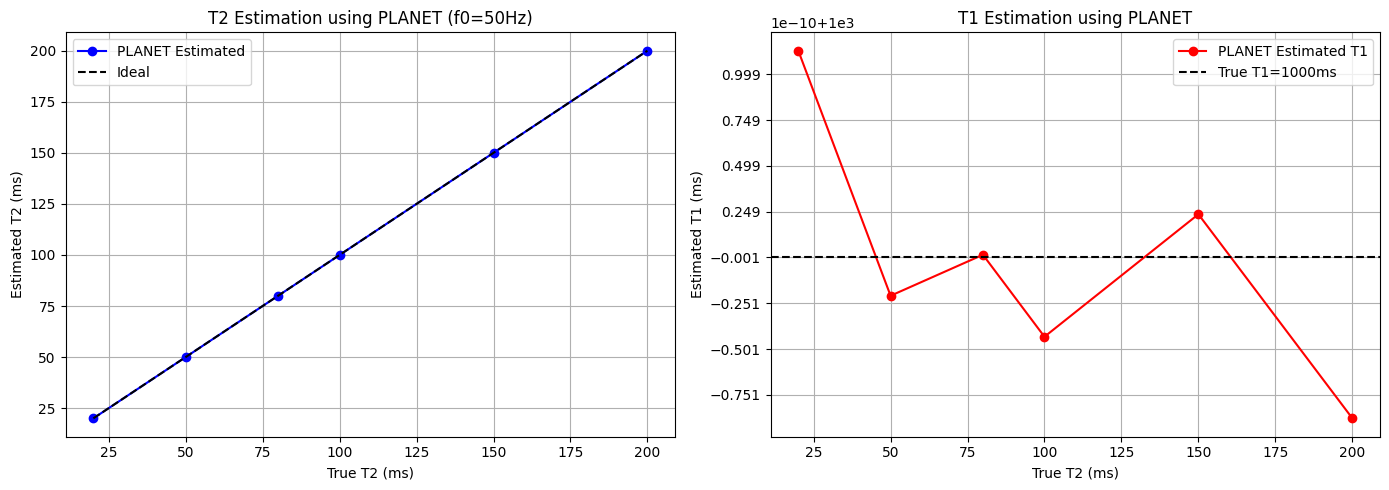

T2 Mean absolute error: 0.00 ms
T1 Mean absolute error: 0.00 ms


In [18]:
# Test T1/T2 estimation using PLANET algorithm
# PLANET requires OFF-RESONANCE signals to form ellipses in the complex plane

true_t2_values = np.array([0.02, 0.05, 0.08, 0.1, 0.15, 0.2])
T1_fixed = 1.0  # Fixed T1
TR = TRs[0]  # Use first TR for PLANET
f0 = 50  # Off-resonance frequency in Hz (REQUIRED for PLANET!)

estimated_t1_planet = []
estimated_t2_planet = []

for t2 in true_t2_values:
    # Simulate with OFF-RESONANCE (f0 != 0) - this creates the ellipse
    TE = TR / 2
    signals = ssfp(T1_fixed, t2, TR, TE, alpha, dphi=pcs, field_map=f0)
    
    # PLANET estimation
    t1_est, t2_est, f0_est = estimate_t1_t2_planet(
        signals[np.newaxis, :], TR, alpha, npcs
    )
    # Extract scalar values
    estimated_t1_planet.append(float(np.atleast_1d(t1_est)[0]))
    estimated_t2_planet.append(float(np.atleast_1d(t2_est)[0]))

estimated_t1_planet = np.array(estimated_t1_planet)
estimated_t2_planet = np.array(estimated_t2_planet)

# Print actual values for debugging
print("Test 1: Varying T2, Fixed T1=1000ms")
print("-" * 50)
print(f"{'True T2 (ms)':<15} {'Est T2 (ms)':<15} {'Est T1 (ms)':<15}")
for i, t2 in enumerate(true_t2_values):
    print(f"{t2*1000:<15.1f} {estimated_t2_planet[i]*1000:<15.2f} {estimated_t1_planet[i]*1000:<15.2f}")
print()

# Plot T2 estimation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(true_t2_values * 1000, estimated_t2_planet * 1000, 'bo-', label='PLANET Estimated')
axes[0].plot(true_t2_values * 1000, true_t2_values * 1000, 'k--', label='Ideal')
axes[0].set_xlabel('True T2 (ms)')
axes[0].set_ylabel('Estimated T2 (ms)')
axes[0].set_title(f'T2 Estimation using PLANET (f0={f0}Hz)')
axes[0].legend()
axes[0].grid(True)

# Plot T1 estimation  
axes[1].plot(true_t2_values * 1000, estimated_t1_planet * 1000, 'ro-', label='PLANET Estimated T1')
axes[1].axhline(T1_fixed * 1000, color='k', linestyle='--', label=f'True T1={T1_fixed*1000:.0f}ms')
axes[1].set_xlabel('True T2 (ms)')
axes[1].set_ylabel('Estimated T1 (ms)')
axes[1].set_title('T1 Estimation using PLANET')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"T2 Mean absolute error: {np.mean(np.abs(estimated_t2_planet - true_t2_values)) * 1000:.2f} ms")
print(f"T1 Mean absolute error: {np.mean(np.abs(estimated_t1_planet - T1_fixed)) * 1000:.2f} ms")

## Test T1 Estimation with PLANET (varying T1)

Test 2: Varying T1, Fixed T2=100ms
--------------------------------------------------
True T1 (ms)    Est T1 (ms)     Est T2 (ms)    
300.0           300.00          100.00         
500.0           500.00          100.00         
800.0           800.00          100.00         
1000.0          1000.00         100.00         
1500.0          1500.00         100.00         
2000.0          2000.00         100.00         



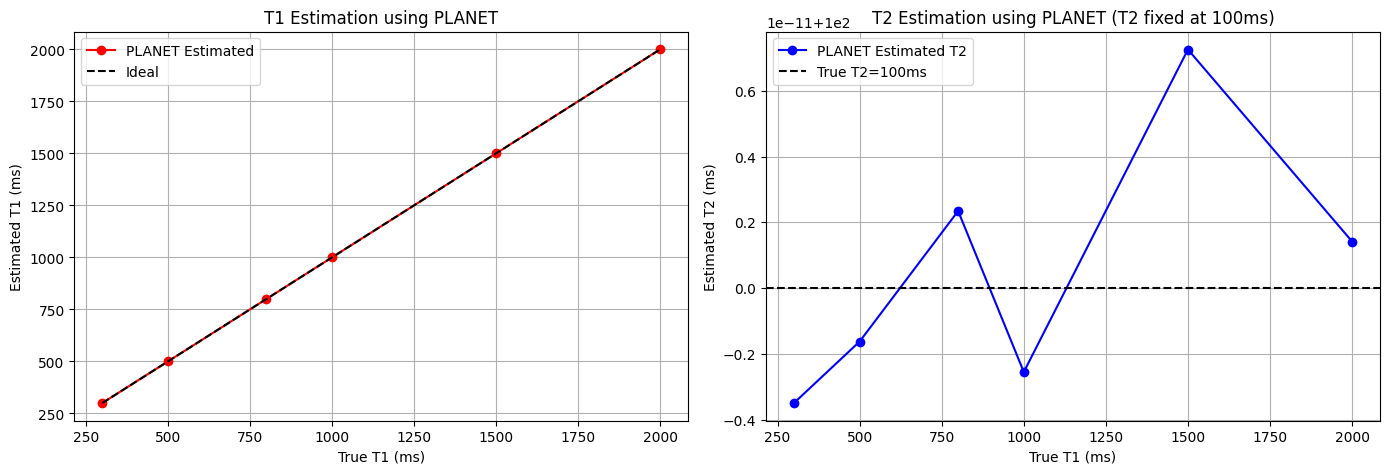

T1 Mean absolute error: 0.00 ms
T2 Mean absolute error: 0.00 ms


In [19]:
# Test PLANET T1 estimation with varying T1 values
true_t1_values = np.array([0.3, 0.5, 0.8, 1.0, 1.5, 2.0])
T2_fixed = 0.1  # Fixed T2
TR = TRs[0]
f0 = 50  # Off-resonance in Hz

estimated_t1 = []
estimated_t2_check = []

for t1 in true_t1_values:
    # Simulate with off-resonance
    TE = TR / 2
    signals = ssfp(t1, T2_fixed, TR, TE, alpha, dphi=pcs, field_map=f0)
    
    t1_est, t2_est, f0_est = estimate_t1_t2_planet(
        signals[np.newaxis, :], TR, alpha, npcs
    )
    # Extract scalar values
    estimated_t1.append(float(np.atleast_1d(t1_est)[0]))
    estimated_t2_check.append(float(np.atleast_1d(t2_est)[0]))

estimated_t1 = np.array(estimated_t1)
estimated_t2_check = np.array(estimated_t2_check)

# Print actual values for debugging
print("Test 2: Varying T1, Fixed T2=100ms")
print("-" * 50)
print(f"{'True T1 (ms)':<15} {'Est T1 (ms)':<15} {'Est T2 (ms)':<15}")
for i, t1 in enumerate(true_t1_values):
    print(f"{t1*1000:<15.1f} {estimated_t1[i]*1000:<15.2f} {estimated_t2_check[i]*1000:<15.2f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(true_t1_values * 1000, estimated_t1 * 1000, 'ro-', label='PLANET Estimated')
axes[0].plot(true_t1_values * 1000, true_t1_values * 1000, 'k--', label='Ideal')
axes[0].set_xlabel('True T1 (ms)')
axes[0].set_ylabel('Estimated T1 (ms)')
axes[0].set_title('T1 Estimation using PLANET')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(true_t1_values * 1000, estimated_t2_check * 1000, 'bo-', label='PLANET Estimated T2')
axes[1].axhline(T2_fixed * 1000, color='k', linestyle='--', label=f'True T2={T2_fixed*1000:.0f}ms')
axes[1].set_xlabel('True T1 (ms)')
axes[1].set_ylabel('Estimated T2 (ms)')
axes[1].set_title('T2 Estimation using PLANET (T2 fixed at 100ms)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"T1 Mean absolute error: {np.mean(np.abs(estimated_t1 - true_t1_values)) * 1000:.2f} ms")
print(f"T2 Mean absolute error: {np.mean(np.abs(estimated_t2_check - T2_fixed)) * 1000:.2f} ms")

## Compare Standard vs Compensated GASP

In [20]:
# Create spectral target profile (Gaussian passband)
#D = responses.gaussian(WIDTH, bw=0.2, shift=0)
D = responses.bandpass(WIDTH, bw=0.2, shift=0)

# Training tissue: Gray Matter (T2/T1 = 0.111, matching analysis notebook)
TRAIN_T1, TRAIN_T2 = 0.9, 0.1
I_train = simulate_tissue(T1=TRAIN_T1, T2=TRAIN_T2)

# Train both methods WITH L2 regularization (matching analysis notebook)
_, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)

# For compensated GASP: use KNOWN T1/T2 values (since we're simulating)
_, coeffs_comp, meta = train_compensated_gasp(
    I_train, D, TRs, alpha, npcs, method='affine',
    known_t1=TRAIN_T1, known_t2=TRAIN_T2,  # Use known values!
    useL2=True, lam=1e-2
)

# Test tissues with different T2/T1 ratios
test_tissues = {
    'Gray Matter (train)': {'T1': 0.9, 'T2': 0.1},    # T2/T1 = 0.111
    'Muscle':              {'T1': 0.9, 'T2': 0.05},   # T2/T1 = 0.055
    'White Matter':        {'T1': 0.6, 'T2': 0.08},   # T2/T1 = 0.133
    'Fat':                 {'T1': 0.25, 'T2': 0.07},  # T2/T1 = 0.28
}

results = []
for name, params in test_tissues.items():
    I_test = simulate_tissue(T1=params['T1'], T2=params['T2'])

    out_std = run_gasp(I_test, coeffs_std, method='affine')
    # Use KNOWN T1/T2 for the test tissue
    out_comp = run_compensated_gasp(
        I_test, coeffs_comp, meta, method='affine',
        known_t1=params['T1'], known_t2=params['T2']
    )

    # Compute RMSE relative to target profile
    rmse_std = np.sqrt(np.mean((np.abs(out_std).flatten() - D) ** 2))
    rmse_comp = np.sqrt(np.mean((np.abs(out_comp).flatten() - D) ** 2))

    results.append({
        'tissue': name,
        'T1': params['T1'],
        'T2': params['T2'],
        'T2/T1': params['T2'] / params['T1'],
        'RMSE_standard': rmse_std,
        'RMSE_compensated': rmse_comp,
        'improvement_%': (rmse_std - rmse_comp) / rmse_std * 100
    })

# Display results
print('=' * 75)
print('AMPLITUDE COMPENSATION RESULTS')
print('=' * 75)
print(f'Training tissue: T1={TRAIN_T1*1000:.0f}ms, T2={TRAIN_T2*1000:.0f}ms, T2/T1={TRAIN_T2/TRAIN_T1:.3f}')
print()
print(f"{'Tissue':<24} {'T2/T1':<8} {'Std RMSE':<12} {'Comp RMSE':<12} {'Improvement':<12}")
print('-' * 75)

for r in results:
    print(f"{r['tissue']:<24} {r['T2/T1']:<8.3f} {r['RMSE_standard']:<12.4f} {r['RMSE_compensated']:<12.4f} {r['improvement_%']:>+8.1f}%")

print('=' * 75)
print('Amplitude compensation normalizes signals across tissue types!')

AMPLITUDE COMPENSATION RESULTS
Training tissue: T1=900ms, T2=100ms, T2/T1=0.111

Tissue                   T2/T1    Std RMSE     Comp RMSE    Improvement 
---------------------------------------------------------------------------
Gray Matter (train)      0.111    0.0589       0.0590           -0.3%
Muscle                   0.056    0.1827       0.0711          +61.1%
White Matter             0.133    0.0808       0.0586          +27.6%
Fat                      0.280    0.3771       0.0694          +81.6%
Amplitude compensation normalizes signals across tissue types!


## Visualize Outputs

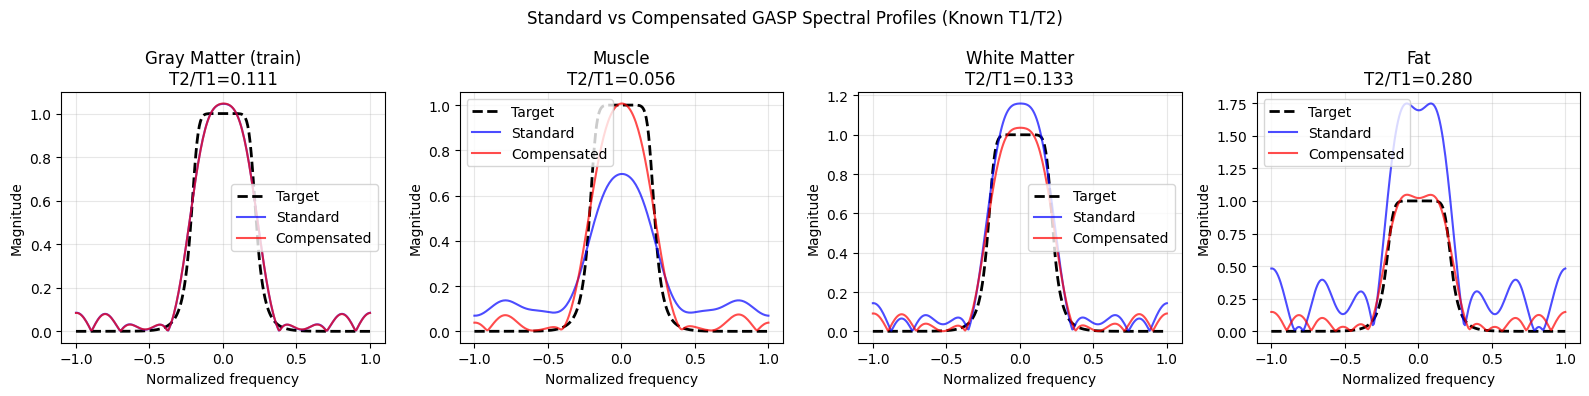

In [21]:
# Visualize spectral profiles
x = np.linspace(-1, 1, WIDTH)

fig, axes = plt.subplots(1, len(test_tissues), figsize=(16, 4))

for i, (name, params) in enumerate(test_tissues.items()):
    I_test = simulate_tissue(T1=params['T1'], T2=params['T2'])

    out_std = np.abs(run_gasp(I_test, coeffs_std, method='affine')).flatten()
    out_comp = np.abs(run_compensated_gasp(
        I_test, coeffs_comp, meta, method='affine',
        known_t1=params['T1'], known_t2=params['T2']
    )).flatten()

    axes[i].plot(x, D, 'k--', label='Target', linewidth=2)
    axes[i].plot(x, out_std, 'b-', label='Standard', alpha=0.7)
    axes[i].plot(x, out_comp, 'r-', label='Compensated', alpha=0.7)
    axes[i].set_title(f'{name}\nT2/T1={params["T2"]/params["T1"]:.3f}')
    axes[i].set_xlabel('Normalized frequency')
    axes[i].set_ylabel('Magnitude')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Standard vs Compensated GASP Spectral Profiles (Known T1/T2)')
plt.tight_layout()
plt.show()